## Görev 6: Türkçe isimlerle WaveNet

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures
%matplotlib inline

In [2]:
!wget -O isimler.txt https://raw.githubusercontent.com/ozymaxx/turkce_dil_verisi/master/tum_isimler.txt

--2026-09-27 06:54:54--  https://raw.githubusercontent.com/ozymaxx/turkce_dil_verisi/master/tum_isimler.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 100199 (98K) [text/plain]
Saving to: ‘isimler.txt’

isimler.txt         100%[===================>]  97.85K  --.-KB/s    in 0.002s  

2026-09-27 06:54:54 (50.5 MB/s) - ‘isimler.txt’ saved [100199/100199]



In [3]:
rows = open('isimler.txt', 'r', encoding='utf-8').read().splitlines()

In [4]:
#data cleaning
words = []
for r in rows:
  isim = r.replace('İ', 'i').replace('I','ı')
  isim = isim.lower()
  isim = isim.strip()
  isim = isim.replace('˜', '')
  isim = isim.replace('.', '')
  isim = isim.replace('â', 'a').replace('î', 'i').replace('û', 'u')
  isim = isim.replace('ĩ', 'i').replace('š', 'ü').replace('¦', 'ğ')
  if len(isim) >= 2 and 'w' not in isim and 'x' not in isim and 'q' not in isim:
    words.append(isim)

print(len(words))
words[:8]

12913


['aba', 'abaca', 'abacan', 'abaç', 'abay', 'abayhan', 'abaza', 'abbas']

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'y', 23: 'z', 24: 'ç', 25: 'ö', 26: 'ü', 27: 'ğ', 28: 'ı', 29: 'ş', 0: '.'}
30


In [6]:
block_size = 8 # context

In [7]:
# build the dataset

def build_dataset(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([74207, 8]) torch.Size([74207])
torch.Size([9196, 8]) torch.Size([9196])
torch.Size([9274, 8]) torch.Size([9274])


In [8]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn ((fan_in,fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self,x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])
#_______________________________________________________________________________
class BatchNorm1d:
  def __init__(self,dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__ (self,x):
    if self.training:
      if x.ndim==2:
        dim = 0
      elif x.ndim ==3:
        dim = (0,1)

      xmean = x.mean(dim,keepdim=True)
      xvar = x.var(dim,keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
## updating___
    if self.training:
      with torch.no_grad():
        self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
 #__________
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]
#_______________________________________________________________________________
class Tanh:
  def __call__(self,x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []
#_______________________________________________________________________________
class Embedding:
  def __init__ (self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__ (self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]
#_______________________________________________________________________________

class FlattenConsecutive:
  def __init__ (self,n):
    self.n = n

  def __call__ (self,x):
    B, T, C = x.shape
    x = x.view(B, T // self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

#_______________________________________________________________________________

class Sequential:

  def __init__ (self,layers):
    self.layers = layers

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters (self):
    return [p for layer in self.layers for p in layer.parameters()]



In [9]:
torch.manual_seed(42);

In [10]:
n_embd = 24
n_hidden= 128

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden,vocab_size),
])
with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
   p.requires_grad = True

77038


In [11]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,),)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) #loss

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # lr decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.4015
  10000/ 200000: 2.4698
  20000/ 200000: 2.0126
  30000/ 200000: 1.8181
  40000/ 200000: 1.6169
  50000/ 200000: 1.7602
  60000/ 200000: 1.6066
  70000/ 200000: 1.7583
  80000/ 200000: 1.3724
  90000/ 200000: 1.8283
 100000/ 200000: 1.8191
 110000/ 200000: 1.7545
 120000/ 200000: 1.2173
 130000/ 200000: 1.3478
 140000/ 200000: 1.6851
 150000/ 200000: 1.3647
 160000/ 200000: 1.4384
 170000/ 200000: 1.5804
 180000/ 200000: 1.4349
 190000/ 200000: 1.5385


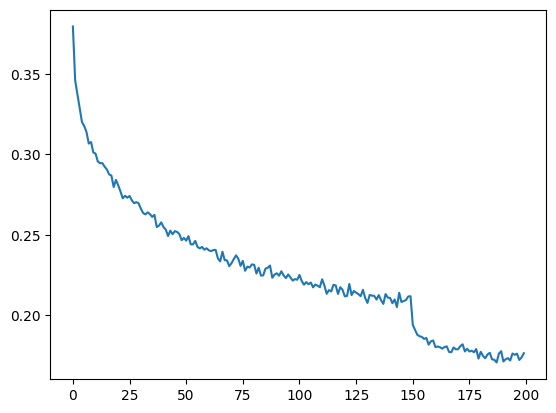

In [12]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [13]:
for layer in model.layers:
  layer.training = False

In [14]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.4484847784042358
val 2.1538329124450684


In [15]:
for layer in model.layers:
  layer.training = False

# sample from the MLP model
for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

koldıs.
inci.
gümüşga.
ğalis.
hiznigül.
berkiye.
dinçer.
altunç.
canay.
konuralp.
şahiner.
vuldur.
tekebaş.
aypel.
mesrure.
özsuncan.
nurlu.
adhan.
balkiyay.
nurşa.
